In [1]:
cd ..

c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = "distilbert-base-uncased"
# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model)
# Load the model
model = DistilBertModel.from_pretrained(model)

In [4]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [5]:
attraction_df = pd.read_csv("./Data/FinalDataset/Data.csv")
ratings_df = pd.read_csv("./Data/FinalDataset/ratings.csv")
ratings_df.head()


,user_id,id,rating
0,1,1,3
1,2,1,5
2,3,1,3
3,4,1,4
4,5,1,5


In [6]:
# Rename the 'id' column to 'place_id'
attraction_df.rename(columns={'id': 'place_id'}, inplace=True)
attraction_df.head()

,place_id,name,description,latitude,longitude,province,location,tags
0,1,Chapat Ganesh Mandir,Chapat Ganesh Temple is Ganesh temple located ...,27.671314,85.328967,Bagmati Province,Bagmati Province,"hindu, temple, pilgrimage"
1,2,Mayadevi Temple,Religious Site The Mayadevi temple is situated...,27.469641,83.275785,Lumbini Province,Lumbini Province,"buddhist, pilgrimage"
2,3,Sikali Mandir,Religious Site Sikali Temple lies in the south...,27.643535,85.285502,Bagmati Province,Kathmandu Valley,"hindu, temple, cultural"
3,4,Bala Guru Sadananda,Bala Guru Sadananda's shrine at his Ashram in ...,27.357001,87.137018,Koshi Province,Shadananda Municipality,"historical, monument"
4,5,21st Century Art Gallery,"21st Century Art Gallery, located in Kathmandu...",27.715548,85.309497,Bagmati Province,Kathmandu,"art_gallery, museum, cultural"


In [7]:
# Add a new column 'attractionID'
attraction_df.dropna(subset=['place_id'], inplace=True)
ratings_df.rename(columns={'id': 'place_id'}, inplace=True)
ratings_df.head()

,user_id,place_id,rating
0,1,1,3
1,2,1,5
2,3,1,3
3,4,1,4
4,5,1,5


In [8]:
# Ensure all values in place_id are numeric before converting to integers
attraction_df['place_id'] = pd.to_numeric(attraction_df['place_id'], errors='coerce').astype('Int64')

ratings_df1 = ratings_df[ratings_df['place_id'].isin(attraction_df['place_id'])]
ratings_df1.head()

,user_id,place_id,rating
0,1,1,3
1,2,1,5
2,3,1,3
3,4,1,4
4,5,1,5


In [9]:
# Check if a GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)

cuda


In [10]:
def generate_embeddings(text):
    # Tokenize the input text and move the input tensors to the device
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        # Pass the inputs through the model
        outputs = model(**inputs)
    
    # Generate embeddings using mean pooling over token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    
    # Optionally move the embeddings back to the CPU
    embeddings = embeddings.cpu().numpy()
    # Debug: Print the shape of the embeddings
    print(f"Generated embeddings shape: {embeddings.shape}")

    return embeddings

                        

In [11]:
# Fill null values in the 'description' column with an empty string
attraction_df['description'] = attraction_df['description'].fillna('')

# Apply the generate_embeddings function to the 'description' column
attraction_df['Embeddings'] = attraction_df['description'].apply(generate_embeddings)


Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings

In [12]:
def custom_cosine_similarity(vector_a, vector_b):
    # Ensure the vectors are numpy arrays
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)
    
    # Calculate the dot product and magnitudes
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    
    # Avoid division by zero
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    
    # Compute cosine similarity
    similarity = dot_product / (magnitude_a * magnitude_b)
    return similarity

In [13]:
attraction_df.info()
attraction_df.to_csv( "./Notebook/Output/Embedding.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1859 entries, 0 to 1858
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   place_id     1859 non-null   Int64  
 1   name         1859 non-null   object 
 2   description  1859 non-null   object 
 3   latitude     1859 non-null   float64
 4   longitude    1859 non-null   float64
 5   province     1859 non-null   object 
 6   location     1859 non-null   object 
 7   tags         1859 non-null   object 
 8   Embeddings   1859 non-null   object 
dtypes: Int64(1), float64(2), object(6)
memory usage: 132.7+ KB


In [28]:
# 2. User Profile Construction
def build_user_profile(user_id):
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    high_rated_places = user_ratings[user_ratings['rating'] >= 4]
    if high_rated_places.empty:
        return None
    
    # Convert embeddings to NumPy arrays
    place_embeddings = np.array(attraction_df[attraction_df['place_id'].isin(high_rated_places['place_id'])]['Embeddings'].tolist())
    
    # Average the embeddings to form the user profile
    if place_embeddings.size == 0:
        print(f"Error: place_embeddings is empty for place_id: {high_rated_places['place_id']}")
        # Handle gracefully or provide a default
        user_profile = np.zeros((768,))
    else:
        user_profile = place_embeddings.mean(axis=0)

    user_profile = place_embeddings.mean(axis=0)
    return user_profile


In [29]:
# 3. Recommendation
def recommend_places(user_id, top_n=5):
    user_profile = build_user_profile(user_id)
    # print(user_profile.shape)
    if user_profile is None:
        return pd.DataFrame(columns=['place_id', 'description', 'similarity'])
    # Calculate similarity between user profile and all attraction embeddings
    similarities = cosine_similarity([user_profile], attraction_df['Embeddings'].tolist()).flatten()
    attraction_df['similarity'] = similarities

    # Sort the attractions by similarity and get top_n recommendations
    recommended_places = attraction_df.sort_values(by='similarity', ascending=False).head(top_n)
    
    return recommended_places[['place_id', 'name' ,'description', 'similarity']]


In [41]:
# Drop rows with NaN values in the 'place_id' column
ratings_df.dropna(subset=['place_id'], inplace=True)

# Convert 'place_id' column to integers
ratings_df['place_id'] = ratings_df['place_id'].astype(int)

user_id = 13
print(f"Places rated by user {user_id}:")
print(ratings_df[ratings_df['user_id'] == user_id])
recommend_places(user_id,10)

Places rated by user 13:
    user_id  place_id  rating
12       13         2       5


,place_id,name,description,similarity
1,2,Mayadevi Temple,Religious Site The Mayadevi temple is situated...,1.000000
2,3,Sikali Mandir,Religious Site Sikali Temple lies in the south...,0.941999
1012,1013,Kakre Bihar,Archaeological Site A small hillock in the mid...,0.938867
544,545,Dharmakirti Mahabihar,Archaeological Site Dharmakirti Bihar is indee...,0.936862
296,297,Birthplace of Gautam Buddha (Lumbini),"The Birthplace of Gautam Buddha, known as Lumb...",0.933927
1575,1576,Nyatapola Temple,Religious Site Nyatapola Temple is the Hindu t...,0.933504
1302,1303,Lumbini,"The birthplace of Lord Buddha, Lumbini is one ...",0.931911
550,551,Divyashwori Temple,Heritage Site Divyashwori temple is one unique...,0.931647
416,417,Chilancho Stupa,Archaeological Site The word Chilancho is form...,0.931347
1829,1830,Yakshyeshwor Temple,Heritage Site The Yakshyeshwor temple or the P...,0.930223


In [31]:
print(attraction_df['Embeddings'].head())


0    [-0.057272054, 0.108186506, 0.04837382, -0.061...
1    [-0.13549657, 0.07388258, -0.06519881, -0.2147...
2    [-0.1111075, 0.12172582, -0.011140166, -0.2895...
3    [0.106655024, 0.1835627, -0.15536307, -0.37485...
4    [-0.0665003, 0.14401945, 0.30438823, -0.054342...
Name: Embeddings, dtype: object


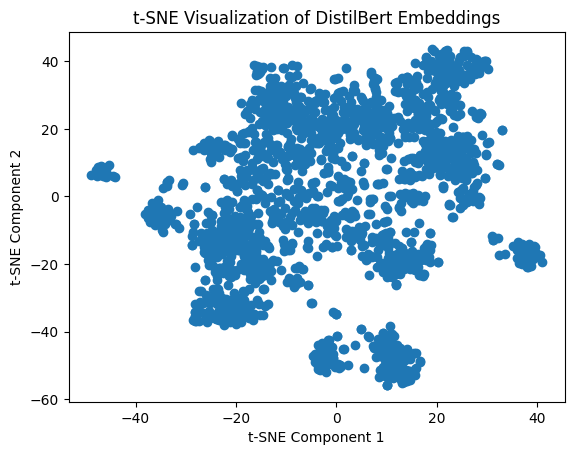

In [32]:

def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])


Average Hit Rate: 0.8867816091954023
Average NDCG: 0.9108019042956239
Average RMSE: 0.018433542772271168
Average Precision: 0.18770114942528737


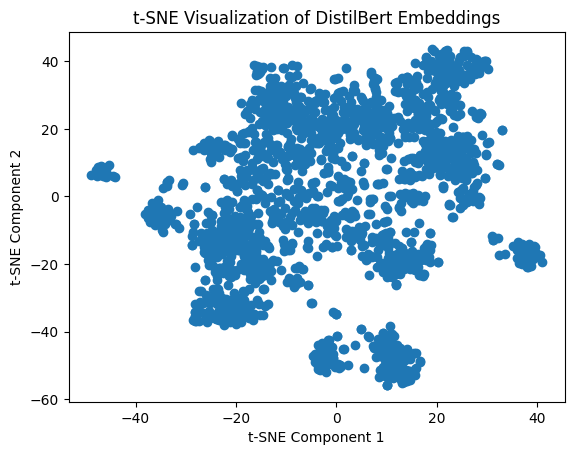

In [36]:

# Define relevance threshold
RELEVANCE_THRESHOLD = 3

# Hit Rate at K
def hit_rate_at_k(recommended_places, relevant_places, k):
    recommended_set = set(recommended_places[:k])
    relevant_set = set(relevant_places)
    return 1 if any(item in recommended_set for item in relevant_set) else 0

# NDCG at K
def ndcg_at_k(recommended_places, relevant_places, k):
    recommended_set = set(recommended_places[:k])
    relevant_set = set(relevant_places)
    
    dcg = 0.0
    idcg = 1.0
    
    for idx, item in enumerate(recommended_places[:k]):
       if item in relevant_set:
           dcg += 1.0 / np.log2(idx + 2)

    return dcg / idcg if relevant_set else 0.0
  
# Function to compute RMSE
def rmse(recommended_place_ids, relevant_place_ids, ratings):
    """Calculates RMSE between predicted and actual ratings."""
    
    if not relevant_place_ids:
        return 0.0 # Return 0 if there is nothing to calculate
    
    # Ensure relevant_place_ids is a set
    relevant_set = set(relevant_place_ids)
    
    # Fetch actual ratings for the relevant places, using the place_id from recommendations
    actual_ratings = ratings_df1[(ratings_df1['place_id'].isin(relevant_set)) & (ratings_df1['user_id'] == user_id)]['rating'].values
    
    # Get predicted ratings (as similarity), using the place_id from recommendations
    predicted_ratings = np.array(attraction_df[attraction_df['place_id'].isin(recommended_place_ids)]['similarity'].values)[:len(actual_ratings)]

    
    # If there aren't predicted ratings for all actual ratings, skip and return 0.0
    if not actual_ratings.size == len(predicted_ratings):
       return 0.0
    
    if not actual_ratings.size:
      return 0.0


    squared_errors = (np.array(predicted_ratings) - np.array(actual_ratings)) ** 2
    rmse_value = np.sqrt(np.mean(squared_errors))

    return rmse_value

#Function to calculate precision at k
def precision_at_k(recommended_places, relevant_places, k):
    recommended_set = set(recommended_places[:k])
    relevant_set = set(relevant_places)
    return len(recommended_set & relevant_set) / k

# Evaluate for a single user
def evaluate_user(user_id, k=5):
    test_user_ratings = ratings_df1[ratings_df1['user_id'] == user_id]
    relevant_places = test_user_ratings[test_user_ratings['rating'] >= RELEVANCE_THRESHOLD]['place_id'].tolist()
    
    if not relevant_places:
        return None  # No relevant places to evaluate
    
    recommendations = recommend_places(user_id, top_n=k)['place_id'].tolist()
    
    hit_rate = hit_rate_at_k(recommendations, relevant_places, k) if recommendations else 0.0
    ndcg = ndcg_at_k(recommendations, relevant_places, k) if recommendations else 0.0
    rmse_value = rmse(recommendations, relevant_places, test_user_ratings['rating'].values) if recommendations else 0.0
    precision = precision_at_k(recommendations, relevant_places, k) if recommendations else 0.0

    return {'hit_rate': hit_rate, 'ndcg': ndcg, 'rmse':rmse_value, 'precision': precision}  


# Evaluate for all users
def evaluate_system(k=5):
    users = ratings_df1['user_id'].unique()
    metrics = {'hit_rate': [], 'ndcg': [], 'rmse': [], 'precision': []}
    
    for user_id in users:
        user_metrics = evaluate_user(user_id, k)
        if user_metrics:
            metrics['hit_rate'].append(user_metrics['hit_rate'])
            metrics['ndcg'].append(user_metrics['ndcg'])
            metrics['rmse'].append(user_metrics['rmse'])
            metrics['precision'].append(user_metrics['precision'])
    
    avg_hit_rate = np.mean(metrics['hit_rate']) if metrics['hit_rate'] else 0.0
    avg_ndcg = np.mean(metrics['ndcg']) if metrics['ndcg'] else 0.0
    avg_rmse = np.mean(metrics['rmse']) if metrics['rmse'] else 0.0
    avg_precision = np.mean(metrics['precision']) if metrics['precision'] else 0.0
    
    return {'avg_hit_rate': avg_hit_rate, 'avg_ndcg': avg_ndcg, 'avg_rmse':avg_rmse, 'avg_precision': avg_precision}


# Ensure embeddings do not contain NaN values
attraction_df['Embeddings'] = attraction_df['Embeddings'].apply(lambda x: np.nan_to_num(x))

# Calculate metrics
results = evaluate_system(k=5)
print("Average Hit Rate:", results['avg_hit_rate'])
print("Average NDCG:", results['avg_ndcg'])
print("Average RMSE:", results['avg_rmse'])
print("Average Precision:", results['avg_precision'])


def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])

In [34]:
print(attraction_df['Embeddings'].isna().sum())
print(attraction_df['Embeddings'].apply(lambda x: np.array(x).shape).unique())


0
[(768,)]
